In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix, log_loss
from imblearn.under_sampling import RandomUnderSampler
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
from statsmodels.miscmodels.ordinal_model import OrderedModel
import joblib

In [33]:
df = pd.read_csv('../../data/interim/olist_ml_processed_review_dataset.csv')

X_raw = df.drop(columns=['review_score']).values
y_raw = df['review_score'].values - 1

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Features go to float32; labels go to long (integers) for CrossEntropyLoss
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# --- Step 4: Create DataLoaders ---
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 256  # Adjust this depending on your preferences

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True          # Shuffle training data to help generalization
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False          # No need to shuffle test/evaluation data
)

print(f"DataLoaders successfully created!")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

DataLoaders successfully created!
Train batches: 133 | Test batches: 34


In [34]:
rus = RandomUnderSampler(random_state=42)
X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)

model = OrderedModel(y_train_balanced, X_train_balanced, distr='logit')

print("Fitting the Ordinal Logistic Regression model...")

res = model.fit(maxiter=300, method='bfgs', disp=True)

Fitting the Ordinal Logistic Regression model...
Optimization terminated successfully.
         Current function value: 1.601048
         Iterations: 19
         Function evaluations: 20
         Gradient evaluations: 20


In [ ]:
predicted_probs = res.model.predict(res.params, exog=X_test)
predicted_classes = np.argmax(predicted_probs, axis=1)

# --- Standard Classification Metrics ---
accuracy = accuracy_score(y_test, predicted_classes)
precision = precision_score(y_test, predicted_classes, average='weighted', zero_division=0)
f1 = f1_score(y_test, predicted_classes, average='weighted', zero_division=0)

# --- Integrated Loss Tracking ---
# 1. Cross-Entropy Loss (Log-Loss) evaluated from predicted probabilities
test_cross_entropy = log_loss(y_test, predicted_probs, labels=np.arange(5))

# 2. Inline Huber Loss Calculation (delta = 1.0) evaluated from class distances
delta = 1.0
error = y_test - predicted_classes
abs_error = np.abs(error)

huber_loss = np.mean(
    np.where(abs_error <= delta, 0.5 * (error ** 2), delta * (abs_error - 0.5 * delta))
)

# --- Print Text Report ---
print("\n" + "="*55)
print("         OLIST 5-CLASS MODEL PERFORMANCE REPORT         ")
print("="*55)
print(f"Overall Accuracy:    {accuracy * 100:.2f}%")
print(f"Weighted Precision:  {precision * 100:.2f}%")
print(f"Weighted F1-Score:   {f1 * 100:.2f}%")
print("-"*55)
print(f"Cross-Entropy Loss:  {test_cross_entropy:.4f}")
print(f"Huber Loss:          {huber_loss:.4f}")
print(f"AIC Score:           {res.aic:.4f}")
print("="*55)

print("\nDetailed Performance Breakdown Across All 5 Classes:")
print(classification_report(y_test, predicted_classes, zero_division=0))


         OLIST 6-CLASS MODEL PERFORMANCE REPORT         
Overall Accuracy:    41.42%
Weighted Precision:  38.10%
Weighted F1-Score:   38.98%
-------------------------------------------------------
Cross-Entropy Loss:  1.5877
Huber Loss:          1.2382
AIC Score:           29579.3451

Detailed Performance Breakdown Across All 6 Classes:
              precision    recall  f1-score   support

         0.0       0.25      0.41      0.31      1576
         1.0       0.07      0.05      0.06       462
         2.0       0.08      0.03      0.05       772
         3.0       0.16      0.07      0.10      1277
         4.0       0.57      0.62      0.60      4377

    accuracy                           0.41      8464
   macro avg       0.23      0.24      0.22      8464
weighted avg       0.38      0.41      0.39      8464



In [36]:
model_save_path = '../../data/model/Reviews_ordinal_logistic_regression.pth'
joblib.dump(res, model_save_path)
print(f"\nTrained statsmodels OrderedModel binary successfully saved to '{model_save_path}'")


Trained statsmodels OrderedModel binary successfully saved to '../../data/model/Reviews_ordinal_logistic_regression.pth'


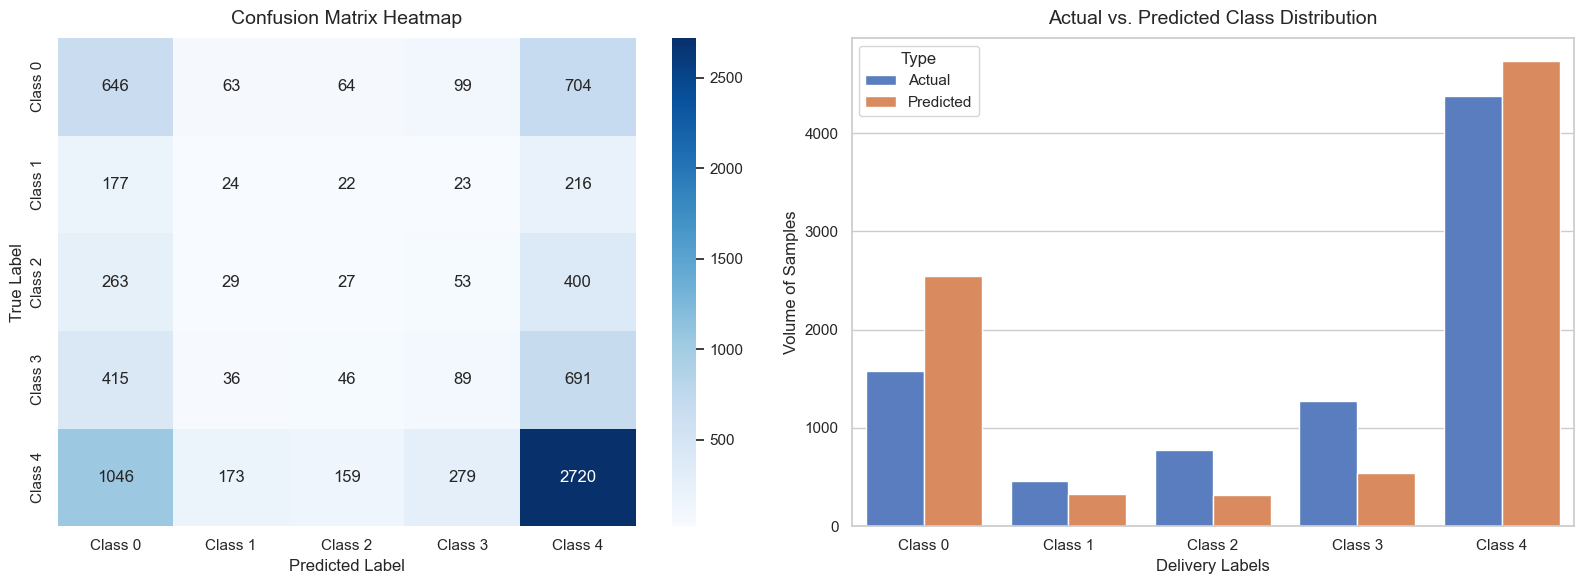

In [38]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, predicted_classes)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    ax=axes[0],
    xticklabels=[f'Class {i}' for i in range(5)],
    yticklabels=[f'Class {i}' for i in range(5)]
)
axes[0].set_title('Confusion Matrix Heatmap', fontsize=14, pad=10)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# Plot B: Actual vs Predicted Class Distribution Comparison
unique, counts_actual = np.unique(y_test, return_counts=True)
unique_pred, counts_pred = np.unique(predicted_classes, return_counts=True)

# Ensure all 5 classes are mapped even if 0 predictions occurred for a minority class
dict_actual = dict(zip(unique, counts_actual))
dict_pred = dict(zip(unique_pred, counts_pred))
data_dist = {
    'Class': [f'Class {i}' for i in range(5)] * 2,
    'Count': [dict_actual.get(i, 0) for i in range(5)] + [dict_pred.get(i, 0) for i in range(5)],
    'Type': ['Actual'] * 5 + ['Predicted'] * 5
}
df_dist = pd.DataFrame(data_dist)

sns.barplot(x='Class', y='Count', hue='Type', data=df_dist, palette='muted', ax=axes[1])
axes[1].set_title('Actual vs. Predicted Class Distribution', fontsize=14, pad=10)
axes[1].set_xlabel('Delivery Labels', fontsize=12)
axes[1].set_ylabel('Volume of Samples', fontsize=12)

plt.tight_layout()
plt.show()